# Introduction

In this notebook, we illustrate our implementation of the semi-analytical European option pricing formula under an Improved Stein-Stein model (LLH) as derived in Lin, Lin & He (2024, *Analytically Pricing European Options under a New Two-Factor Stochastic Volatility Model*). The prices obtained from the formula are compared to Monte Carlo prices and the implmentation is tested against edge cases where the LLH model reduces to the classical Black-Scholes model and the stochastic volatility models of Stein-Stein (1990, *Stock price distributions with stochastic volatility*) and Schobel-Zhu (1999, *Stochastic volatility with an Ornstein-Uhlenbeck:an extension*).



### Note on the LLH paper

Our implementation corrects an error present in the formula of Lin, Lin & He (2024).  Specifically, the ODE system for the characteristic function coefficients $D,\,E,\,F,\,G,\,H$ (shown below) is **autonomous** — it depends only on the current state, not on the time to maturity $\tau$. The paper's presentation suggests a  $\tau$-dependent right-hand side for $\frac{\partial D}{\partial \tau}$, which is incorrect.

The close agreement between our rectified numerical LLH prices and independent Monte Carlo estimates throughout this notebook serves as evidence that this correction is valid.

## Contents

1. [LLH Model](#llh-model) 
2. [Price Paths Simulation](#simulate)
3. [LLH Pricing Forumla](#llh-formula) 
4. [LLH Formula vs Monte Carlo](#european-prices)
   - 3.1 One-month horizon
   - 3.2 One-year horizon
5. [Timing: Numerical LLH vs Monte Carlo](#timing) 
6. [Edge-Case Validation](#edge-cases)
   - 5.1 Black-Scholes model (1973) 
   - 5.2 Stein & Stein model (1991)  
   - 5.3 Schöbel & Zhu model (1999) 

<a id="llh-model"></a>
## 1. Improved Stein-Stein Model (LLH)

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated Brownian motions, $W_t$ independent Brownian motion
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters

<a id="simulate"></a>
## 2. Price Paths Simulation

We illustrate simulation of price paths from the LLH model following Algorithm 2.5 found in the report.
Model parameters are taken from the Lin-Lin-He paper, Tables 1 and 2 respectively. Here, $10, 000$ thousand paths are sampled over a $1-$year horizon with $252$ trading days.

In [1]:
import sys, time
sys.path.insert(0, '../src')

import priceModels as pm
from amOptPricer import price_call_bs
from reporting import llh_vs_mc, llh_vs_mc_timing, sz_table2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

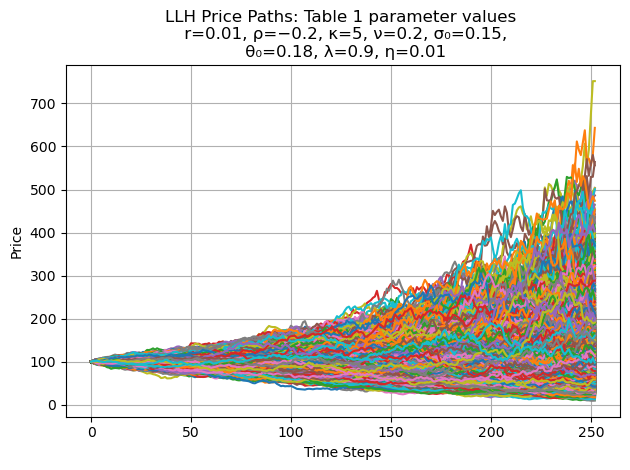

In [2]:
# Model with Lin-Lin-He paper-Table 1 parameters
model_t1 = pm.ImprovedSteinStein(
    r=0.01, rho=-0.2, kappa=5, nu=0.2,
    sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=123
)

# Simulate and plot price paths
res_t1 = model_t1.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_t1['S'].T, title="LLH Price Paths: Table 1 parameter values \n r=0.01, ρ=−0.2, κ=5, ν=0.2, σ₀=0.15,\n θ₀=0.18, λ=0.9, η=0.01")

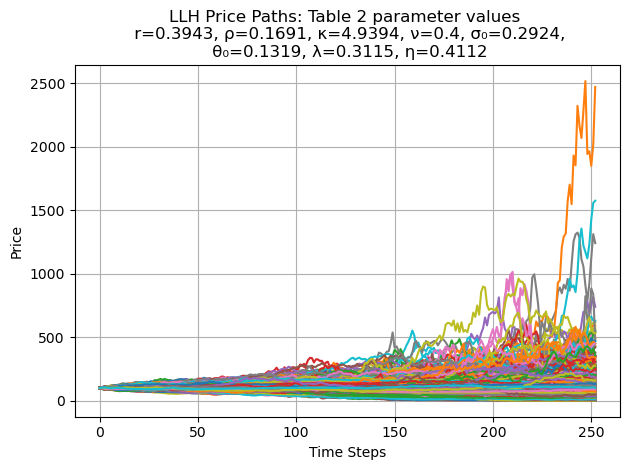

In [3]:
# Model with Lin-Lin-He paper-Table 2 parameters
model_t2 = pm.ImprovedSteinStein(
    r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943,
    sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123
)

# Simulate and plot price paths
res_t2 = model_t2.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)
pm.plot(res_t2['S'].T, title="LLH Price Paths: Table 2 parameter values \n r=0.3943, ρ=0.1691, κ=4.9394, ν=0.4, σ₀=0.2924,\n θ₀=0.1319, λ=0.3115, η=0.4112")

<a id="llh-pricing"></a>
## 3. LLH Pricing Formula

The price $U$ of a European option under LLh model is computed using the following formula derived in Lin, Lin & He (2024).

$$
U(\tau;S_t,K)
= S_t\,P_1(\tau;K) - K e^{-r\tau}\,P_2(\tau;K)
$$
where for $j=1,2:$

\begin{equation}
\begin{aligned}
    P_j(\tau;K) 
&= \tfrac{1}{2}
  + \frac{1}{\pi}\int_{0}^{\infty}
      Re\left[
        \frac{e^{-i\phi\ln K}}{i\phi}\,
        f_j(\tau;\phi)
      \right]\,d\phi\\
f_j(\tau;\phi)
&= \exp\!\big(
  C + D\,\sigma_t^2 + E\,\sigma_t\theta_t + F\,\theta_t^2 + G\,\theta_t + H\,\sigma_t + i\phi\,x_t
\big)
\end{aligned}
\end{equation}

where $x_t=\ln S_t$ and the parameters $D,\,E,\,F,\,G,\,H$ satisfy the system of ODEs:

\begin{equation}
\begin{aligned}
\frac{\partial D}{\partial \tau}(\tau;\phi)
&= \left(u_j\, i\phi - \tfrac{1}{2}\phi^2\right)
   + 2\nu^{2} D^2(\tau;\phi) - 2A(\phi)\,D(\tau;\phi)
   + \tfrac{1}{2}\eta^{2} E^2(\tau;\phi), \\[4pt]
\frac{\partial E}{\partial \tau}(\tau;\phi)
&= 2\kappa\,D(\tau;\phi) - A(\phi)\,E(\tau;\phi)
   + 2\nu^{2} D(\tau;\phi)E(\tau;\phi)
   + 2\eta^{2} E(\tau;\phi)F(\tau;\phi), \\[4pt]
\frac{\partial F}{\partial \tau}(\tau;\phi)
&= \kappa\,E(\tau;\phi)
   + \tfrac{1}{2}\nu^{2} E^2(\tau;\phi)
   + 2\eta^{2} F^2(\tau;\phi), \\[4pt]
\frac{\partial G}{\partial \tau}(\tau;\phi)
&= \kappa\,H(\tau;\phi) + 2\lambda\,F(\tau;\phi)
   + \nu^{2} E(\tau;\phi)H(\tau;\phi)
   + 2\eta^{2} F(\tau;\phi)G(\tau;\phi), \\[4pt]
\frac{\partial H}{\partial \tau}(\tau;\phi)
&= -A(\phi)\,H(\tau;\phi) + \lambda\,E(\tau;\phi)
   + 2\nu^{2} D(\tau;\phi)H(\tau;\phi)
   + \eta^{2} E(\tau;\phi)G(\tau;\phi), \\[4pt]
\frac{\partial C}{\partial \tau}(\tau;\phi)
&= r\, i\phi + \lambda\,G(\tau;\phi)
   + \tfrac{1}{2}\nu^{2} H^2(\tau;\phi) + \nu^{2} D(\tau;\phi)
   + \tfrac{1}{2}\eta^{2} G^2(\tau;\phi) + \eta^{2} F(\tau;\phi)
\end{aligned}
\end{equation}
with $u_1=\tfrac{1}{2},\, u_2=-\tfrac{1}{2},\,
b_1=1,\, b_2=0,\,
A(\phi)=\kappa-\nu\rho\,(b_j+i\phi), \, x=\ln S_t$ and the initial conditions 
$$C(0;\phi)=D(0;\phi)=E(0;\phi)=F(0;\phi)=G(0;\phi)=H(0;\phi)=0$$

Here, $\tau = T-t$ is the remaining time until maturity of the option and $\phi$ is a dummy (frequency) parameter.

In [4]:
#Set options parameters
S0, K, tau = 100.0, 90.0, 1.0

#Set Quadrature and ODE solver parameters
phi_max, n_phi, n_steps_ode = 300.0, 500, 100

# Price European call via LLH formula for Table 1 parameters
print(
    model_t1.price_call_llh(S=S0, K=K, tau=tau,                                   
                        phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode,
                        vol=model_t1.sigma0, theta=model_t1.theta0)
)

[25.79140282]


<a id="european-prices"></a>
## 4. LLH Formula vs Monte Carlo

We compute European option prices using the rectified semi-analytical formula from
Lin, Lin & He (2024) and compare with Monte Carlo
estimates from 1,000,000 simulated paths. Results are shown for both
parameter sets (Tables 1 and 2 from LLH paper) across two time horizons: one month and one year. Scenarios have been considered for in-the-money, at-the-money, and out-the-money options.


### Note on Pricing European Puts 

* The LLH price of a European put has been computed using the call-put partiy: $P_E^{\text{LLH}} = C_E^{\text{LLH}} + Ke^{-r\tau} - S$
* The MC price a European put has been computed as $P_E^{\text{MC}} = \mathbb{E}\left[e^{-r\tau}\max(0, K-S_T)\right]$

### 4.1 One-month horizon ($\tau = 1/12$ yr, 22 trading days)

In [5]:
# Set parameters for option pricing
# Spot price values
S_vals = [90.0, 95.0, 100.0, 105.0, 110.0]

# Strike price values 
K_vals = [100.0, 90.0, 100.0, 110.0, 105.0]

# Time to maturity
tau = 0.083

# Number of trading days in a month, used for Monte Carlo time step
n_steps_mc = 22

# Monte Carlo 
n_paths = 1_000_000

#### Lin, Lin & He (2024) — Table 1 parameters

In [6]:
# Compute and display option prices
call_df, put_df = llh_vs_mc(model_t1, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [7]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,0.020092,0.019503,-3.02,"[0.0190, 0.0200]"
95.0,90.0,5.373783,5.374378,0.01,"[5.3666, 5.3821]"
100.0,100.0,1.899232,1.896501,-0.14,"[1.8911, 1.9019]"
105.0,110.0,0.413589,0.410613,-0.72,"[0.4080, 0.4133]"
110.0,105.0,5.544537,5.544500,-0.00,"[5.5358, 5.5532]"


In [8]:
print("European Put Prices")
display(put_df)

European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,9.937126,9.930050,-0.07,"[9.9219, 9.9382]"
95.0,90.0,0.299114,0.292861,-2.14,"[0.2908, 0.2950]"
100.0,100.0,1.816267,1.806327,-0.55,"[1.8010, 1.8117]"
105.0,110.0,5.322327,5.311782,-0.20,"[5.3034, 5.3201]"
110.0,105.0,0.457423,0.449457,-1.77,"[0.4466, 0.4523]"


We notice that the relative bias jumps modestly for options priced at out-the-money spot.

#### Lin, Lin & He (2024) — Table 2 parameters

In [9]:
# Compute and display option prices
call_df, put_df = llh_vs_mc(model_t2, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [10]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,0.392372,0.392213,-0.04,"[0.3887, 0.3957]"
95.0,90.0,6.066585,6.088004,0.35,"[6.0756, 6.1004]"
100.0,100.0,3.140889,3.160870,0.63,"[3.1509, 3.1709]"
105.0,110.0,1.506520,1.515834,0.61,"[1.5084, 1.5232]"
110.0,105.0,6.445675,6.470950,0.39,"[6.4570, 6.4849]"


In [12]:
print("European Put Prices")
display(put_df)

European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,10.309406,10.297057,-0.12,"[10.2846, 10.3095]"
95.0,90.0,0.991916,1.000467,0.85,"[0.9958, 1.0052]"
100.0,100.0,3.057923,3.064360,0.21,"[3.0559, 3.0728]"
105.0,110.0,6.415257,6.410350,-0.08,"[6.3985, 6.4222]"
110.0,105.0,1.358561,1.368936,0.76,"[1.3630, 1.3749]"


For this set of model parameters, the relative bias remains within 1% for all options types. The price process resulting from the model under these parameters is more volatile and the model seems to gauage the price well in this case.

### 4.2 One-year horizon ($\tau = 1.0$ yr, 52 weekly steps)

In [13]:
# Time to maturity
tau = 1.0

# Number of trading days in a month, used for Monte Carlo time step
n_steps_mc = 52

# Reduce number of paths to 500,000 to reduce computational cost
n_paths = 500_000


#### Lin, Lin & He (2024) — Table 1 parameters

In [ ]:
# Compute and display option prices 
call_df, put_df = llh_vs_mc(model_t1, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [15]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,15.604471,15.494567,-0.71,"[15.3980, 15.5911]"
95.0,90.0,22.428989,22.378881,-0.22,"[22.2642, 22.4935]"
100.0,100.0,21.388416,21.313441,-0.35,"[21.1971, 21.4298]"
105.0,110.0,20.529176,20.428778,-0.49,"[20.3107, 20.5469]"
110.0,105.0,25.623710,25.562384,-0.24,"[25.4303, 25.6945]"


In [16]:
print("European Put Prices")
display(put_df)

European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,24.609455,24.409019,-0.82,"[24.3423, 24.4757]"
95.0,90.0,16.533474,16.387806,-0.89,"[16.3326, 16.4430]"
100.0,100.0,20.393399,20.217834,-0.87,"[20.1545, 20.2812]"
105.0,110.0,24.434657,24.228641,-0.85,"[24.1572, 24.3001]"
110.0,105.0,19.578943,19.406968,-0.89,"[19.3423, 19.4717]"


#### Lin, Lin & He (2024) — Table 2 parameters

In [17]:
call_df, put_df = llh_vs_mc(model_t2, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [18]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,8.728264,8.144590,-7.17,"[8.0279, 8.2613]"
95.0,90.0,15.353155,14.754768,-4.06,"[14.6253, 14.8842]"
100.0,100.0,13.678589,12.992458,-5.28,"[12.8584, 13.1265]"
105.0,110.0,12.367477,11.640699,-6.24,"[11.5020, 11.7794]"
110.0,105.0,17.377769,16.672947,-4.23,"[16.5234, 16.8225]"


In [19]:
print("\nEuropean Put Prices")
display(put_df)


European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,17.733248,17.211074,-3.03,"[17.1050, 17.3172]"
95.0,90.0,9.457640,8.924171,-5.98,"[8.8177, 9.0306]"
100.0,100.0,12.683573,12.065775,-5.12,"[11.9519, 12.1797]"
105.0,110.0,16.272959,15.617931,-4.19,"[15.4965, 15.7393]"
110.0,105.0,11.333001,10.703347,-5.88,"[10.5798, 10.8269]"


Again, for this set of parameters, the relative bias jumps more significantly over the 1 year horizon for the more volatile price process.

#### Remarks
- The put-call parity: $P-C=Ke^{-r\tau}-S$ implies $C_E^{\text{LLH}}-C^{\text{MC}}_E \approx P_E^{\text{LLH}}-P^{\text{MC}}_E$, so the absolute bias is comparable for calls and puts.
- **It is worth experimenting with different sets of values of the quadrature and ODE solver parameters, and increased MC steps for in/at/out of the money options.**

<a id="timing"></a>
## 5. Timing: Numerical LLH vs Monte Carlo

We compare the wall-clock cost of computing a single European call price via
the analytical LLH formula (ODE + quadrature) versus Monte Carlo simulation,
for both the one-month and one-year horizons. Several pricing repetitions are timed and the median across runs is reported.  

In [20]:
S0, K = 100.0, 90.0
n_paths = 500_000

scenarios = [("1 month", 0.083, 22),                                                             
               ("1 year",   1.0,   52)]                                                               
display(
    llh_vs_mc_timing(model_t2, S0, K, scenarios, n_paths,                                        
                        phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)       
)

,Label,tau,LLH,MC,Time_LLH,Time_MC,Speedup
0,1 month,0.083,10.363730,10.376439,0.037474,3.830401,102.215100
1,1 year,1.000,18.757414,18.220246,0.037140,8.252048,222.185415


<a id="edge-cases"></a>
## 5. Edge-Case Validation

We verify the LLH implementation against known limiting cases. When the
stochastic volatility parameters are switched off, the model should recover
Black-Scholes, Stein-Stein, and Schobel-Zhu prices exactly.

### 5.1 Black-Scholes (1973) limit: $\kappa=\nu=\lambda=\eta=\rho=0$

Setting all stochastic volatility parameters to zero reduces the LLH model to
geometric Brownian motion. The LLH formula should match the closed-form
Black-Scholes price to machine precision.

#### Simulate Price Paths

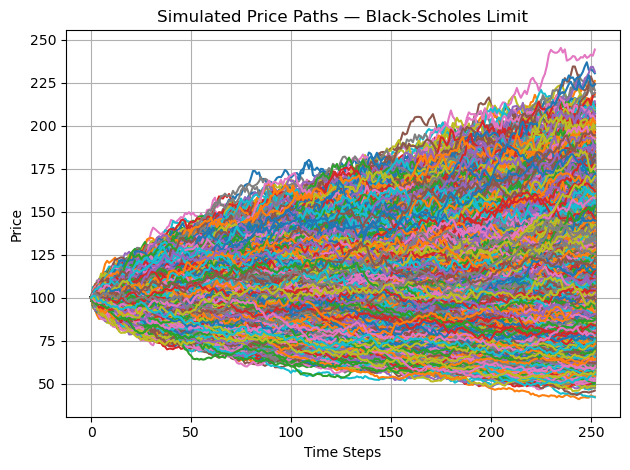

In [21]:
model_bs = pm.ImprovedSteinStein(
    r=0.05, rho=0.0, kappa=0.0, nu=0.0,
    sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=123
)
res_bs = model_bs.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=100000)
pm.plot(res_bs['S'].T, title="Simulated Price Paths — Black-Scholes Limit")

#### Test of Lognormality

We draw price paths from the LLH (BS-limit) model and consider the price slice
at the end of the horizon $T$. It should follow the BS log-normal distribution.

In [23]:
pm.test_lognormality(res_bs['S'][:, -1])

KS statistic: 0.0019, p-value: 0.8672
Fail to reject null: data may be lognormal.


#### Compare European Option Prices

In [24]:
S, K, tau, vol, theta = 100, 90, 1.0, 0.2, 0.0
price_llh = model_bs.price_call_llh(S, K, tau, vol, theta).item()
price_bs  = price_call_bs(S=100, K=90, tau=1.0, r=0.05, vol=0.2)
price_mc  = model_bs.price_call_mc(res_bs, K=90)['price']

print(f"LLH (BS-limit) = {price_llh:.10f}")
print(f"Black-Scholes  = {price_bs:.10f}")
print(f"|Δ|            = {abs(price_llh - price_bs):.3e}")
print(f"Monte Carlo    = {price_mc:.10f}")

LLH (BS-limit) = 16.6994484084
Black-Scholes  = 16.6994484084
|Δ|            = 5.684e-14
Monte Carlo    = 16.7662242340


### 5.2 Stein & Stein (1991) limit: $\lambda=\eta=\rho=0$

Setting $\lambda=\eta=0$ removes the time-varying long-run mean $\theta_t$,
and $\rho=0$ removes leverage. This recovers the original Stein & Stein (1991)
model. We compare against their Table 1 values.

#### Simulate Price Paths

Note: In the Stein-Stein paper,
$\delta := \kappa = 4, \quad k := \nu = 0.1, \quad \mu := r = 0.0953, \quad \sigma := \text{vol} = 0.2$

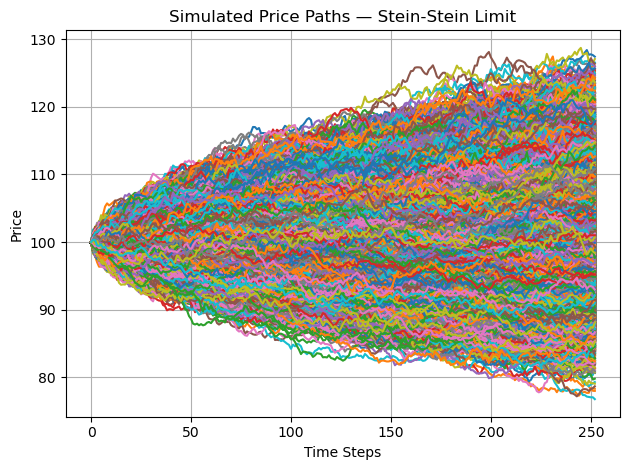

In [25]:
model_ss = pm.ImprovedSteinStein(
    r=0.0953, rho=0.0, kappa=4.0, nu=0.1,
    sigma0=0.2, theta0=0.2, lam=0.0, eta=0.0, seed=123
)
res_ss = model_ss.simulate_prices(S0=100.0, T=1.0/12, n_steps_mc=252, n_paths=100000)
pm.plot(res_ss['S'].T, title="Simulated Price Paths — Stein-Stein Limit")

#### Compare European Option Prices

In [26]:
S, K, tau, vol, theta = 100, 90, 1/12, 0.2, 0.2
price_llh = model_ss.price_call_llh(S, K, tau, vol, theta).item()
price_ss  = 10.77  # from Stein-Stein paper Table 1
price_mc  = model_ss.price_call_mc(res_ss, K=90)['price']

print(f"LLH (SS-limit)  = {price_llh:.10f}")
print(f"Stein-Stein     = {price_ss:.10f}")
print(f"|Δ|             = {abs(price_llh - price_ss):.3e}")
print(f"Monte Carlo     = {price_mc:.10f}")

LLH (SS-limit)  = 10.7668609302
Stein-Stein     = 10.7700000000
|Δ|             = 3.139e-03
Monte Carlo     = 10.7764814126


<a id="sz-table2"></a>
## 5.3 Schöbel & Zhu (1999) limit: $\lambda=\eta=0$

Schöbel & Zhu (1999) extend Stein & Stein (1991) by allowing $\rho \neq 0$,introducing leverage via correlation between the asset and volatility Brownians. Setting $\lambda=\eta=0$ in the LLH model recovers the Schöbel–Zhu dynamics.   We compare against their Table 2 values across $\rho \in {0.5, 0.0, -0.5}$ and $\theta \in {0.0, 0.1, 0.2, 0.3}$. The goal here is to validate the implementation, not to study the impact of $\theta_0$ on the price.


**Schöbel & Zhu (1999) — Table 2**

![Schöbel & Zhu (1999) — Table 2](../figs/table2_sch-zhu.png)

In [27]:
r_sz, kappa_sz, nu_sz = 0.0953, 4.0, 0.1
sigma0_sz = 0.15
tau_sz    = 0.5
S_sz      = 100.0
K_sz      = [90, 95, 100, 105, 110, 115, 120]
theta_values = [0.0, 0.1, 0.2, 0.3]

rho_cases = {"Table 2 (ρ = 0.5)": 0.5,
             "Table 2 (ρ = 0.0)": 0.0,
             "Table 2 (ρ = −0.5)": -0.5}

In [28]:
bs_prices = {K: price_call_bs(S=S_sz, K=K, tau=tau_sz, r=r_sz, vol=sigma0_sz)
             for K in K_sz}

tables = sz_table2(rho_cases, theta_values, K_sz, bs_prices,
                        r=r_sz, kappa=kappa_sz, nu=nu_sz,
                        sigma0=sigma0_sz, S0=S_sz, tau=tau_sz)

for name, df in tables.items():
    print(f'\n=== {name} ===')
    display(df)


=== Table 2 (ρ = 0.5) ===


,90,95,100,105,110,115,120
Table 2 (ρ = 0.5) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.189000,9.459500,5.141400,2.173000,0.763200,0.243700,0.074900
MC θ₀=0.0,14.203300,9.479000,5.179400,2.216400,0.788600,0.252400,0.077100
LLH θ₀=0.1,14.262400,9.841900,6.131700,3.466200,1.812100,0.894900,0.425000
MC θ₀=0.1,14.265200,9.848500,6.139100,3.474000,1.819500,0.900600,0.427800
LLH θ₀=0.2,14.722600,10.804000,7.550600,5.043600,3.239500,2.014200,1.220400
MC θ₀=0.2,14.707700,10.784300,7.526600,5.020100,3.218400,1.996900,1.208700
LLH θ₀=0.3,15.607600,12.082000,9.109000,6.703200,4.828000,3.413500,2.376200
MC θ₀=0.3,15.568900,12.034900,9.057700,6.652300,4.779400,3.368100,2.338600



=== Table 2 (ρ = 0.0) ===


,90,95,100,105,110,115,120
Table 2 (ρ = 0.0) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.200500,9.526900,5.268600,2.170200,0.645200,0.150000,0.030400
MC θ₀=0.0,14.212300,9.544700,5.299000,2.211800,0.670800,0.156600,0.031500
LLH θ₀=0.1,14.351200,9.996700,6.254000,3.451000,1.678600,0.731300,0.292200
MC θ₀=0.1,14.350500,9.997000,6.254500,3.456100,1.686400,0.737800,0.294800
LLH θ₀=0.2,14.871100,10.951600,7.632200,5.022000,3.124000,1.844700,1.040200
MC θ₀=0.2,14.850100,10.926000,7.602600,4.994900,3.102000,1.828000,1.030800
LLH θ₀=0.3,15.753700,12.197600,9.161000,6.676400,4.727400,3.258600,2.191800
MC θ₀=0.3,15.708900,12.144300,9.104200,6.621400,4.676500,3.213000,2.155400



=== Table 2 (ρ = −0.5) ===


,90,95,100,105,110,115,120
Table 2 (ρ = −0.5) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.224500,9.600000,5.371900,2.152300,0.504200,0.061100,0.004300
MC θ₀=0.0,14.236000,9.616500,5.396500,2.191400,0.532400,0.067100,0.005200
LLH θ₀=0.1,14.440600,10.129500,6.360800,3.435100,1.529400,0.544700,0.154900
MC θ₀=0.1,14.436200,10.125100,6.356600,3.438100,1.538700,0.553100,0.158000
LLH θ₀=0.2,15.003200,11.083600,7.709900,5.003000,3.004400,1.660200,0.842100
MC θ₀=0.2,14.977600,11.053000,7.675600,4.973100,2.981400,1.644900,0.835400
LLH θ₀=0.3,15.887000,12.306000,9.212900,6.652400,4.626500,3.096900,1.995200
MC θ₀=0.3,15.837500,12.247200,9.151600,6.594200,4.573800,3.051200,1.960600
